In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import seaborn as sns
pd.set_option('display.max_rows', None)

In [2]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')

In [3]:
x_cols = ['Avg source IP count', 'Detect count', 'Victim IP', 'Port number', 
          'Packet speed', 'Data speed', 'Avg packet len', 'Source IP count', 
          'Packet speed_normalized', 'Data speed_normalized', 'time_of_day',
          'Avg packet len_normalized', 'total_seconds', 'weekday_number', 
          'IsWeekend', 'Start Hour', 'Sin_Hour', 'Cos_Hour', 'DayOfYear', 
          'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_DetectCount', 'Std_DetectCount', 
          'Min_DetectCount', 'Max_DetectCount', 'VictimIP_Count', 'PortNumber_Count', 
          'AvgPacketLen_Mean', 'AvgPacketLen_Std', 'DataSpeed_PacketSpeed', 
          'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second', 
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 
          'Is_DNS', 'Is_POP3', 'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 
          'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 'Is_TFTP', 'Is_MySQL', 
          'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081', 
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 
          'Is_NTP', 'Is_Kerberos', 'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 
          'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 'Is_BGP', 'Is_IMAPS_Alt', 
          'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 
          'Is_Modbus', 'Is_CoAP', 'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 
          'Is_Elasticsearch', 'Is_Zookeeper', 'Is_Cassandra', 'Is_Docker', 
          'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 'Is_DHCPv6', 
          'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH']

In [4]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Assuming you have your data loaded into 'train' and 'test' DataFrames
# and 'x_cols' is a list of feature column names.

# Separate features (X) and target (y) for training and testing
X_train = train[x_cols]
y_train = train['Type']
X_test = test[x_cols]
y_test = test['Type']

# Initialize the individual classifiers
rf_clf = RandomForestClassifier(n_estimators=437, random_state=42, max_depth=37, min_samples_split=10, min_samples_leaf=5, verbose=0)
lgbm_clf = lgb.LGBMClassifier(verbose=-1, n_estimators=351, learning_rate=0.05719243532859288, num_leaves=47, max_depth=5, min_child_samples=42, subsample=0.8896113748808988, colsample_bytree=0.9577482057904019, random_state=42)
xgb_clf = xgb.XGBClassifier(objective='multi:softmax', num_class=3,booster=('gbtree'),alpha=0.8929914624140356,subsample=0.5245590585473099,colsample_bytree=0.41745486572446977,max_depth=10,eta=0.03343544751435021,gamma=0.36103800824329335,grow_policy='lossguide',min_child_weight=2,eval_metric='merror',  random_state=42,)

Stacking classifier results:
Accuracy: 0.7234
Precision (weighted): 0.6747
Recall (weighted): 0.7234
F1 (weighted): 0.6614

Classification report:
               precision    recall  f1-score   support

           0       0.50      0.11      0.19    305167
           1       0.75      0.94      0.83    919196
           2       0.07      0.06      0.06     22903

    accuracy                           0.72   1247266
   macro avg       0.44      0.37      0.36   1247266
weighted avg       0.67      0.72      0.66   1247266



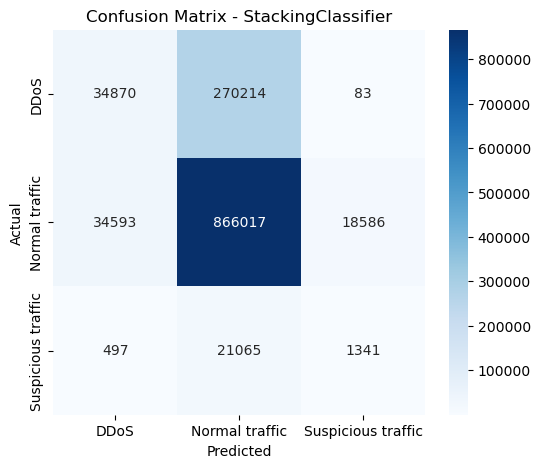

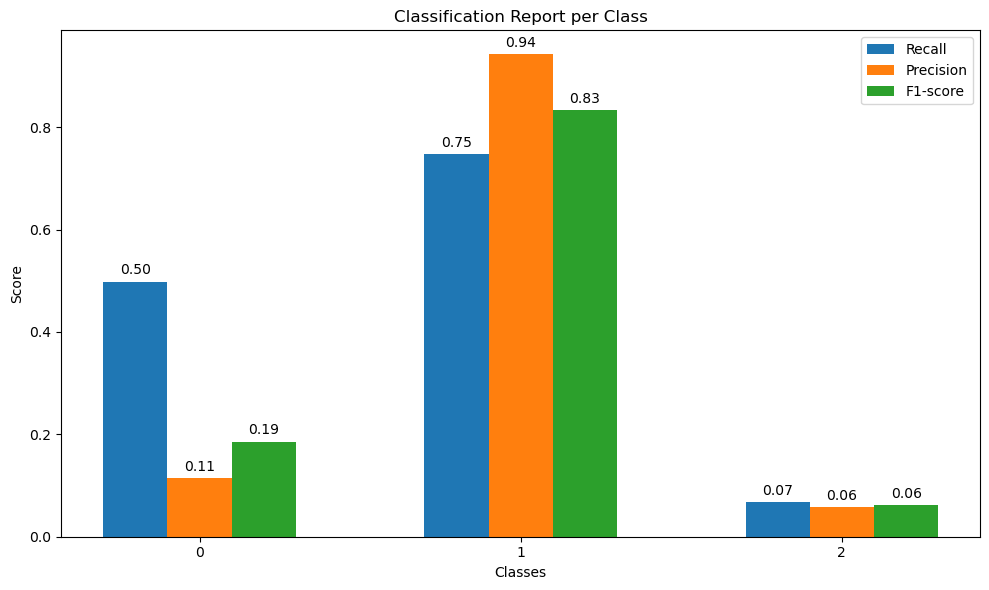

In [5]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Build stacking classifier using existing base models
estimators = [
    #('knn', knn),
    #('gnb', None),
    ('rfc', rf_clf),
    ('lgbm', lgbm_clf),
    ('xgb', xgb_clf),
]

# Use the tuned `knn` (created by the Optuna cell) as the final estimator
#{'n_neighbors': 2, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 77, 'p': 2, 'metric': 'manhattan'}
# Use the tuned `dtree` (created by the Optuna cell) as the final estimator
#{'max_depth': 4, 'min_samples_leaf': 819, 'criterion': 'gini'}

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=KNeighborsClassifier(),
    stack_method='predict_proba'
)

# Train
stack_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = stack_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Stacking classifier results:\nAccuracy: {acc:.4f}\nPrecision (weighted): {prec:.4f}\nRecall (weighted): {rec:.4f}\nF1 (weighted): {f1:.4f}\n")
print("Classification report:\n", classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
class_labels = ['DDoS', 'Normal traffic', 'Suspicious traffic']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - StackingClassifier')
plt.show()

report = classification_report(test['Type'], y_pred, output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Build stacking classifier using existing base models
estimators = [
    #('knn', knn),
    #('gnb', None),
    ('rfc', rf_clf),
    ('lgbm', lgbm_clf),
    ('xgb', xgb_clf),
]

# Use the tuned `knn` (created by the Optuna cell) as the final estimator
#{'n_neighbors': 2, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 77, 'p': 2, 'metric': 'manhattan'}
# Use the tuned `dtree` (created by the Optuna cell) as the final estimator
#{'max_depth': 4, 'min_samples_leaf': 819, 'criterion': 'gini'}

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=KNeighborsClassifier(),
    stack_method='predict_proba',
    passthrough = True
)

# Train
stack_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = stack_clf.predict(X_test)

TypeError: 'list' object is not callable

Stacking classifier results:
Accuracy: 0.7768
Precision (weighted): 0.7785
Recall (weighted): 0.7768
F1 (weighted): 0.7771

Classification report:
               precision    recall  f1-score   support

           0       0.57      0.60      0.58    305167
           1       0.85      0.85      0.85    919196
           2       0.59      0.38      0.46     22903

    accuracy                           0.78   1247266
   macro avg       0.67      0.61      0.63   1247266
weighted avg       0.78      0.78      0.78   1247266



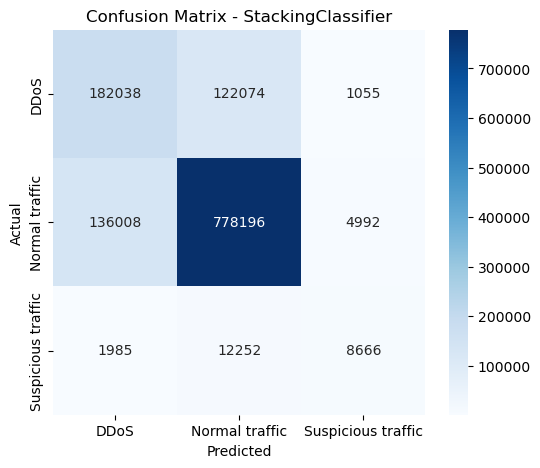

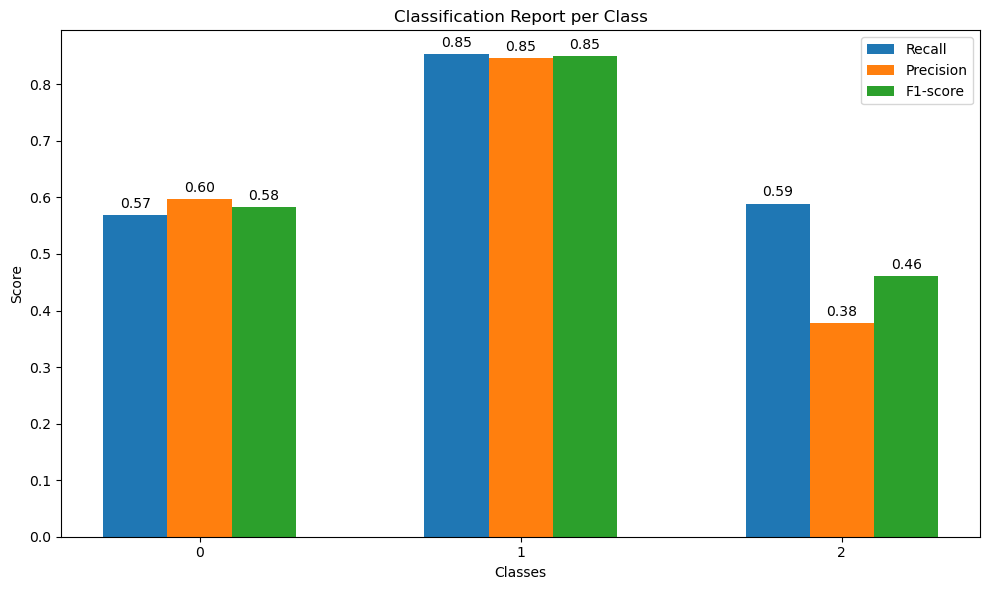

In [8]:
from sklearn.metrics import f1_score

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Stacking classifier results:\nAccuracy: {acc:.4f}\nPrecision (weighted): {prec:.4f}\nRecall (weighted): {rec:.4f}\nF1 (weighted): {f1:.4f}\n")
print("Classification report:\n", classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
class_labels = ['DDoS', 'Normal traffic', 'Suspicious traffic']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - StackingClassifier')
plt.show()

report = classification_report(test['Type'], y_pred, output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()


c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Stacking classifier results:
Accuracy: 0.7381
Precision (weighted): 0.7011
Recall (weighted): 0.7381
F1 (weighted): 0.6343

Classification report:
               precision    recall  f1-score   support

           0       0.57      0.02      0.04    305167
           1       0.74      1.00      0.85    919196
           2       0.92      0.00      0.00     22903

    accuracy                           0.74   1247266
   macro avg       0.74      0.34      0.30   1247266
weighted avg       0.70      0.74      0.63   1247266



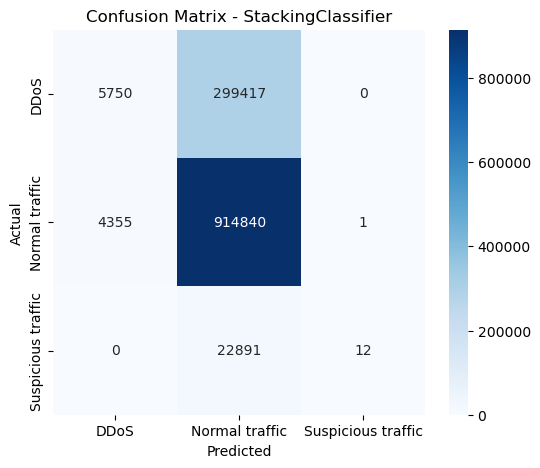

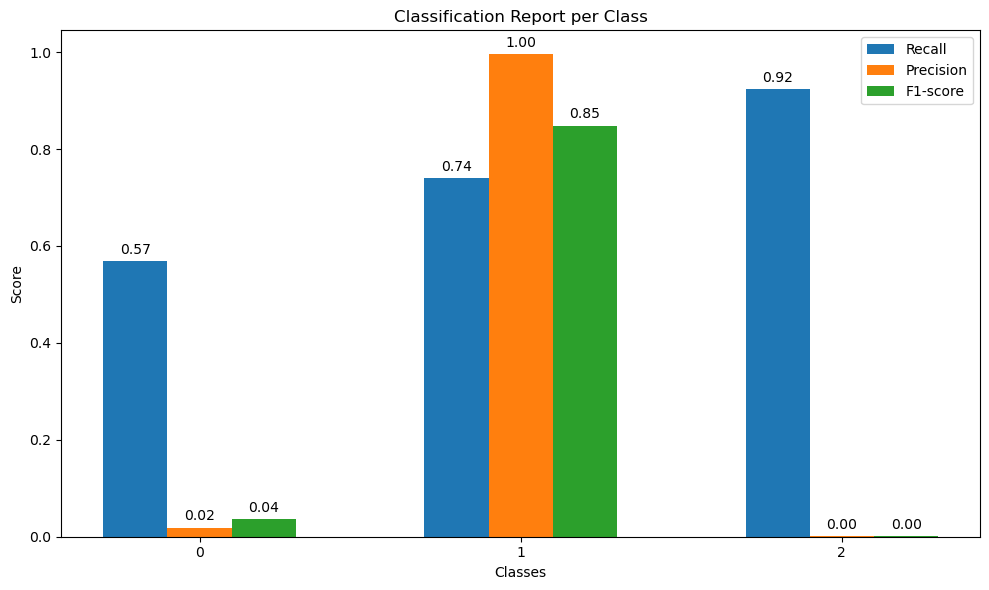

In [5]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

# Build stacking classifier using existing base models
estimators = [
    #('knn', knn),
    #('gnb', None),
    ('rfc', rf_clf),
    ('lgbm', lgbm_clf),
    ('xgb', xgb_clf),
]

# Use the tuned `knn` (created by the Optuna cell) as the final estimator
#{'n_neighbors': 2, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 77, 'p': 2, 'metric': 'manhattan'}
# Use the tuned `dtree` (created by the Optuna cell) as the final estimator
#{'max_depth': 4, 'min_samples_leaf': 819, 'criterion': 'gini'}

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state = 42),
    stack_method='predict_proba'
)

# Train
stack_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = stack_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Stacking classifier results:\nAccuracy: {acc:.4f}\nPrecision (weighted): {prec:.4f}\nRecall (weighted): {rec:.4f}\nF1 (weighted): {f1:.4f}\n")
print("Classification report:\n", classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
class_labels = ['DDoS', 'Normal traffic', 'Suspicious traffic']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - StackingClassifier')
plt.show()

report = classification_report(test['Type'], y_pred, output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()


c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Stacking classifier results:
Accuracy: 0.7597
Precision (weighted): 0.7888
Recall (weighted): 0.7597
F1 (weighted): 0.6766

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.10      0.18    305167
           1       0.75      1.00      0.86    919196
           2       0.00      0.00      0.00     22903

    accuracy                           0.76   1247266
   macro avg       0.57      0.37      0.35   1247266
weighted avg       0.79      0.76      0.68   1247266



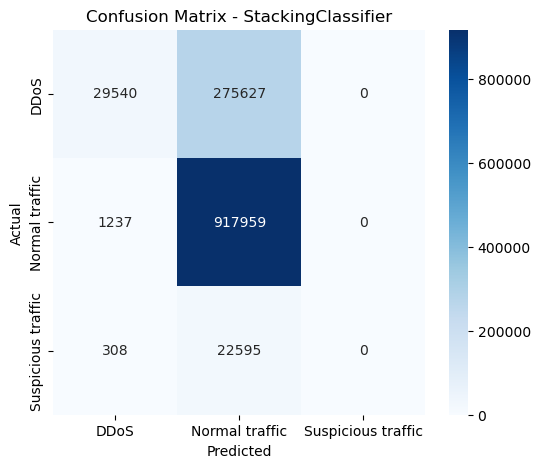

c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


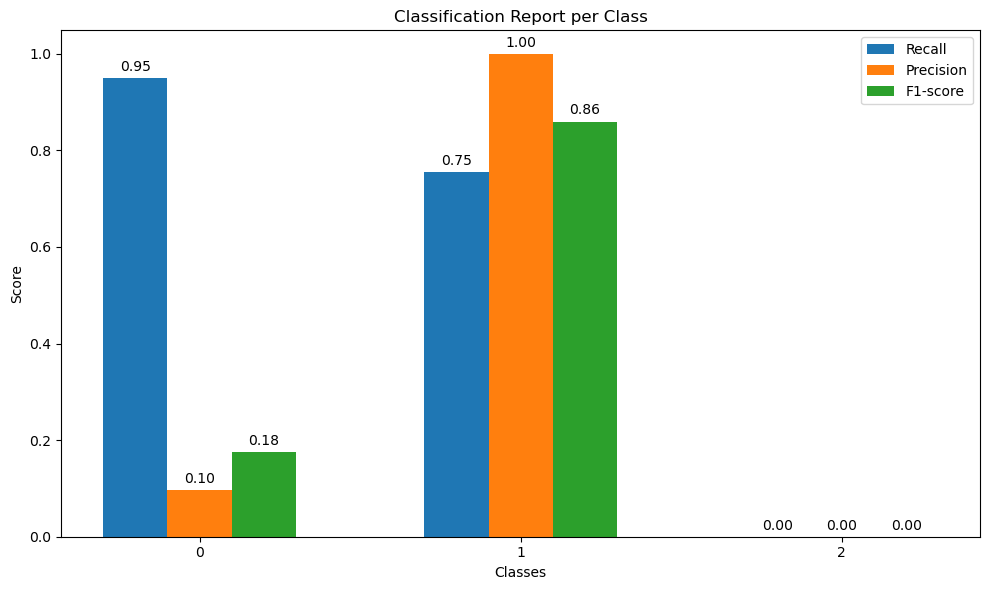

In [6]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

# Build stacking classifier using existing base models
estimators = [
    #('knn', knn),
    #('gnb', None),
    ('rfc', rf_clf),
    ('lgbm', lgbm_clf),
    ('xgb', xgb_clf),
]

# Use the tuned `knn` (created by the Optuna cell) as the final estimator
#{'n_neighbors': 2, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 77, 'p': 2, 'metric': 'manhattan'}
# Use the tuned `dtree` (created by the Optuna cell) as the final estimator
#{'max_depth': 4, 'min_samples_leaf': 819, 'criterion': 'gini'}

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state = 42),
    stack_method='predict_proba',
    passthrough = True
)

# Train
stack_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = stack_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Stacking classifier results:\nAccuracy: {acc:.4f}\nPrecision (weighted): {prec:.4f}\nRecall (weighted): {rec:.4f}\nF1 (weighted): {f1:.4f}\n")
print("Classification report:\n", classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
class_labels = ['DDoS', 'Normal traffic', 'Suspicious traffic']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - StackingClassifier')
plt.show()

report = classification_report(test['Type'], y_pred, output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()


Stacking classifier results:
Accuracy: 0.2219
Precision (weighted): 0.5493
Recall (weighted): 0.2219
F1 (weighted): 0.2578

Classification report:
               precision    recall  f1-score   support

           0       0.27      0.44      0.33    305167
           1       0.66      0.15      0.24    919196
           2       0.01      0.33      0.03     22903

    accuracy                           0.22   1247266
   macro avg       0.31      0.31      0.20   1247266
weighted avg       0.55      0.22      0.26   1247266



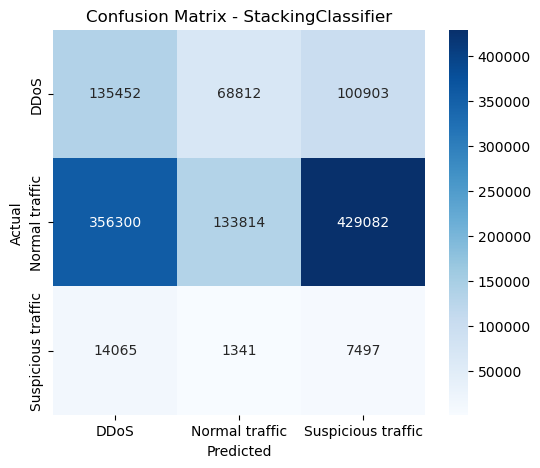

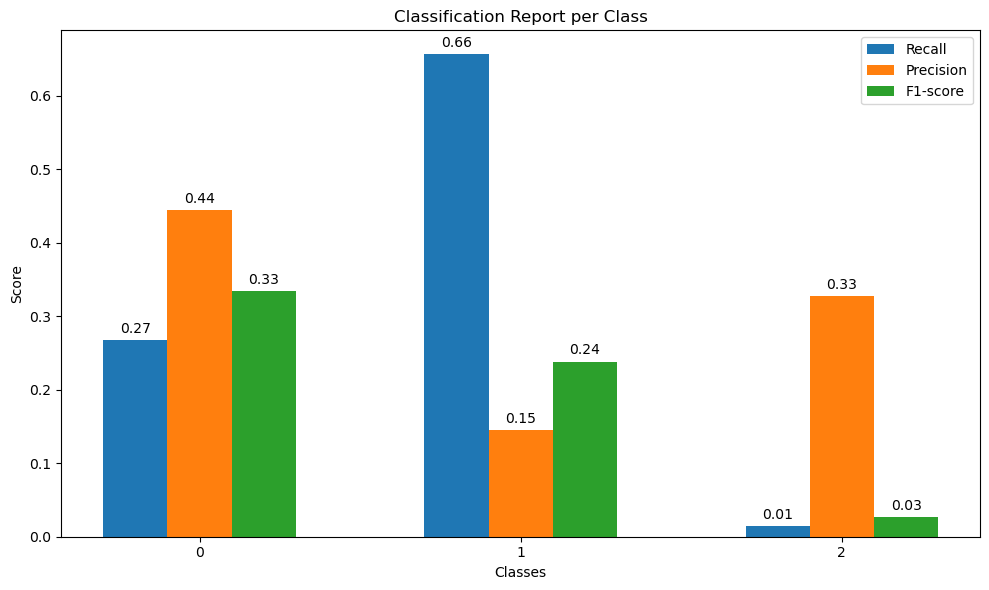

In [7]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

# Build stacking classifier using existing base models
estimators = [
    #('knn', knn),
    #('gnb', None),
    ('rfc', rf_clf),
    ('lgbm', lgbm_clf),
    ('xgb', xgb_clf),
]

# Use the tuned `knn` (created by the Optuna cell) as the final estimator
#{'n_neighbors': 2, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 77, 'p': 2, 'metric': 'manhattan'}
# Use the tuned `dtree` (created by the Optuna cell) as the final estimator
#{'max_depth': 4, 'min_samples_leaf': 819, 'criterion': 'gini'}

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=DecisionTreeClassifier(random_state = 42),
    stack_method='predict_proba',
    passthrough = True
)

# Train
stack_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = stack_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Stacking classifier results:\nAccuracy: {acc:.4f}\nPrecision (weighted): {prec:.4f}\nRecall (weighted): {rec:.4f}\nF1 (weighted): {f1:.4f}\n")
print("Classification report:\n", classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
class_labels = ['DDoS', 'Normal traffic', 'Suspicious traffic']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - StackingClassifier')
plt.show()

report = classification_report(test['Type'], y_pred, output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()


Stacking classifier results:
Accuracy: 0.6734
Precision (weighted): 0.6314
Recall (weighted): 0.6734
F1 (weighted): 0.6456

Classification report:
               precision    recall  f1-score   support

           0       0.33      0.19      0.24    305167
           1       0.75      0.85      0.79    919196
           2       0.12      0.12      0.12     22903

    accuracy                           0.67   1247266
   macro avg       0.40      0.39      0.38   1247266
weighted avg       0.63      0.67      0.65   1247266



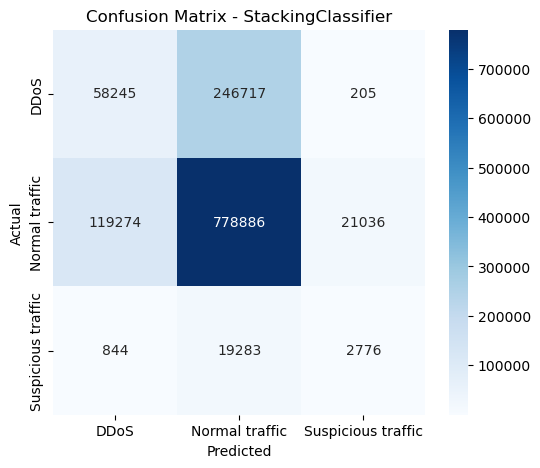

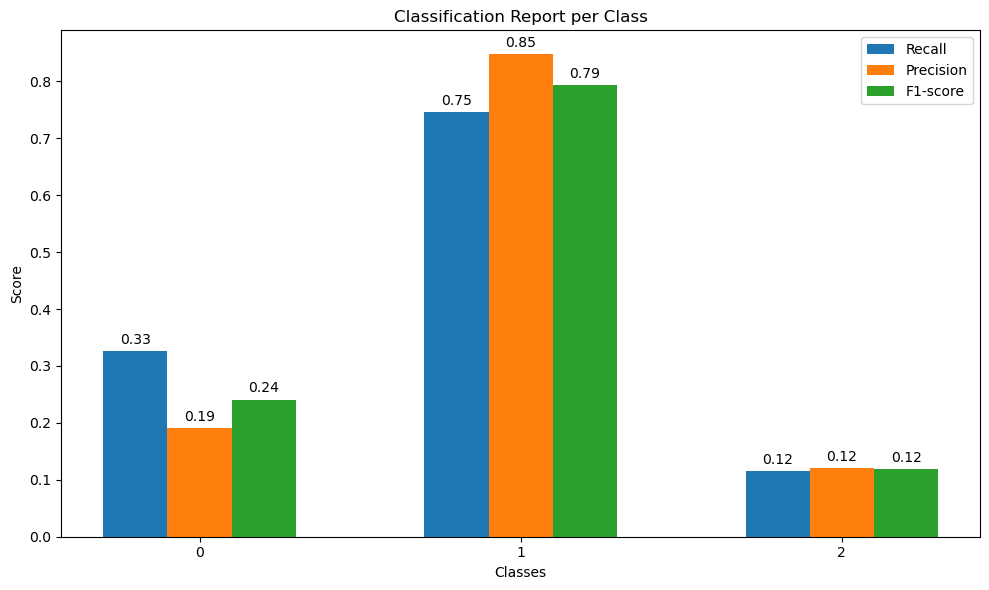

In [8]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

# Build stacking classifier using existing base models
estimators = [
    #('knn', knn),
    #('gnb', None),
    ('rfc', rf_clf),
    ('lgbm', lgbm_clf),
    ('xgb', xgb_clf),
]

# Use the tuned `knn` (created by the Optuna cell) as the final estimator
#{'n_neighbors': 2, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 77, 'p': 2, 'metric': 'manhattan'}
# Use the tuned `dtree` (created by the Optuna cell) as the final estimator
#{'max_depth': 4, 'min_samples_leaf': 819, 'criterion': 'gini'}

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=DecisionTreeClassifier(random_state = 42),
    stack_method='predict_proba'
)

# Train
stack_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = stack_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Stacking classifier results:\nAccuracy: {acc:.4f}\nPrecision (weighted): {prec:.4f}\nRecall (weighted): {rec:.4f}\nF1 (weighted): {f1:.4f}\n")
print("Classification report:\n", classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
class_labels = ['DDoS', 'Normal traffic', 'Suspicious traffic']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - StackingClassifier')
plt.show()

report = classification_report(test['Type'], y_pred, output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()
